# CVRP — Solución Exacta: Formulación de Laporte & Nobert (1983)

**Asignatura:** Optimización en Ingeniería — Magíster en Ingeniería Informática, USACH
**Informe Nro. 1:** Métodos Clásicos de Optimización Combinatorial
**Referencia:** Laporte, G. & Nobert, Y. (1983). *A Branch and Bound Algorithm for the Capacitated Vehicle Routing Problem.* OR Spektrum, 5, 77-85.

---

## Pipeline
1. Carga de instancias del Set A (CVRPLIB) desde carpeta local
2. Parsing del archivo `.vrp` y lectura del óptimo desde el `.sol`
3. Modelo matemático (PuLP/CBC): formulación de dos índices con generación iterativa de cortes de capacidad (RCI)
4. Ejecución experimental: una pasada por instancia (método exacto determinista)
5. Resultados: tabla detallada y grilla de rutas

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# 0. Instalación de dependencias
# ============================================================
import subprocess, sys

for pkg in ["pulp", "requests", "matplotlib", "networkx", "numpy", "pandas"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pulp import (
    LpProblem, LpMinimize, LpVariable, lpSum, LpStatus, value, PULP_CBC_CMD
)

print("Dependencias cargadas correctamente.")



Dependencias cargadas correctamente.


## 1. Funciones de descarga y parsing

In [5]:
# ============================================================
# 1. Descarga y parsing de instancias CVRPLIB
# ============================================================

BASE = "/content/drive/MyDrive/Laboratorios Optimización 2026"
DATA_DIRS = {
    "A": f"{BASE}/A",
    "E": f"{BASE}/E",
}

def load_instance(name):
    set_id = name.split("-")[0]          # "A-n32-k5" -> "A", "E-n13-k4" -> "E"
    with open(f"{DATA_DIRS[set_id]}/{name}.vrp") as f:
        return f.read()

def load_optimum(name):
    set_id = name.split("-")[0]
    with open(f"{DATA_DIRS[set_id]}/{name}.sol") as f:
        for line in f:
            if line.strip().lower().startswith("cost"):
                return int(line.split()[-1])
    return None

def parse_vrp(text):
    lines = text.strip().split("\n")
    section = None
    coords, demands = {}, {}
    edge_weights = []                      # tokens de EDGE_WEIGHT_SECTION
    capacity = dimension = None
    name, ew_type, ew_format = "", "EUC_2D", None
    for line in lines:
        line = line.strip()
        if line.startswith("NAME"):
            name = line.split(":")[1].strip()
        elif line.startswith("DIMENSION"):
            dimension = int(line.split(":")[1].strip())
        elif line.startswith("CAPACITY"):
            capacity = int(line.split(":")[1].strip())
        elif line.startswith("EDGE_WEIGHT_TYPE"):
            ew_type = line.split(":")[1].strip()
        elif line.startswith("EDGE_WEIGHT_FORMAT"):
            ew_format = line.split(":")[1].strip()
        elif line.startswith("NODE_COORD_SECTION"):
            section = "coord"; continue
        elif line.startswith("EDGE_WEIGHT_SECTION"):
            section = "weights"; continue
        elif line.startswith("DEMAND_SECTION"):
            section = "demand"; continue
        elif line.startswith(("DEPOT_SECTION", "EOF", "DISPLAY_DATA")):
            section = None; continue
        if section == "coord":
            p = line.split()
            if len(p) >= 3:
                coords[int(p[0])] = (float(p[1]), float(p[2]))
        elif section == "weights":
            edge_weights.extend(int(round(float(t))) for t in line.split())
        elif section == "demand":
            p = line.split()
            if len(p) >= 2:
                demands[int(p[0])] = int(p[1])
    n = dimension
    nodes = list(range(1, n + 1))
    clients = [i for i in nodes if i != 1]
    total_demand = sum(demands[i] for i in clients)
    m_min = math.ceil(total_demand / capacity)
    k_match = re.search(r"-k(\d+)", name)
    m_given = int(k_match.group(1)) if k_match else m_min
    assert m_given >= m_min, f"m={m_given} inconsistente (m_min={m_min})"
    return {"name": name, "n": n, "nodes": nodes, "depot": 1, "clients": clients,
            "coords": coords, "demands": demands, "capacity": capacity,
            "m": m_given, "m_min": m_min,
            "ew_type": ew_type, "ew_format": ew_format,
            "edge_weights": edge_weights}


def build_distance_matrix(inst):
    nodes, n = inst["nodes"], inst["n"]
    dist = {(i, i): 0 for i in nodes}
    if inst["ew_type"] == "EUC_2D":
        c = inst["coords"]
        for i in nodes:
            for j in nodes:
                if i < j:
                    d = round(math.sqrt((c[i][0]-c[j][0])**2 + (c[i][1]-c[j][1])**2))
                    dist[i, j] = dist[j, i] = d
    elif inst["ew_type"] == "EXPLICIT":
        w = iter(inst["edge_weights"])
        fmt = inst["ew_format"]
        if fmt == "LOWER_ROW":            # filas del triángulo inferior, sin diagonal
            for i in range(2, n + 1):
                for j in range(1, i):
                    dist[i, j] = dist[j, i] = next(w)
        elif fmt == "UPPER_ROW":          # filas del triángulo superior, sin diagonal
            for i in range(1, n):
                for j in range(i + 1, n + 1):
                    dist[i, j] = dist[j, i] = next(w)
        else:
            raise ValueError(f"EDGE_WEIGHT_FORMAT no soportado: {fmt}")
        assert next(w, None) is None, "Sobraron pesos: revisa el formato declarado"
    else:
        raise ValueError(f"EDGE_WEIGHT_TYPE no soportado: {inst['ew_type']}")
    return dist


## 2. Modelo Matemático — Laporte & Nobert (1983)

### Formulación simétrica (págs. 78-79)

**Variables:** $x_{ij}$ para $i < j$, con $x_{1j} \in \{0,1,2\}$ y $x_{ij} \in \{0,1\}$ para $i \geq 2$

**Objetivo:** $\min z = \sum_{i<j} c_{ij} x_{ij}$

**Eq. 1 (grado depósito):** $\sum_{j=2}^{n} x_{1j} = 2m$

**Eq. 2 (grado cliente):** $\sum_{i<k} x_{ik} + \sum_{j>k} x_{kj} = 2 \quad \forall k \in \{2,...,n\}$

**Eq. 3 (subtour/capacidad, generados iterativamente):**
$$\sum_{\substack{i,j \in S \\ i<j}} x_{ij} \leq |S| - \left\lceil \frac{\sum_{i \in S} d_i}{D} \right\rceil \quad \forall S \subseteq N \setminus \{1\}$$

In [6]:
# ============================================================
# 2. Funciones del modelo y resolución
# ============================================================

def build_model(inst, dist):
    """Construye el modelo base con restricciones de grado (Eq. 1-2)."""
    nodes = inst["nodes"]
    clients = inst["clients"]
    depot = inst["depot"]
    m = inst["m"]

    edges = [(i, j) for i in nodes for j in nodes if i < j]

    prob = LpProblem("CVRP_Laporte1983", LpMinimize)

    x = {}
    for (i, j) in edges:
        ub = 2 if i == depot else 1
        x[i, j] = LpVariable(f"x_{i}_{j}", 0, ub, cat="Integer")

    prob += lpSum(dist[i, j] * x[i, j] for (i, j) in edges), "FO_costo_total"

    # Eq. 1: grado del depósito = 2m
    prob += (lpSum(x[depot, j] for j in clients) == 2 * m, "Eq1_grado_deposito")

    # Eq. 2: grado de cada cliente = 2
    for k in clients:
        prob += (
            lpSum(x[i, j] for (i, j) in edges if i == k or j == k) == 2,
            f"Eq2_grado_{k}"
        )

    return prob, x, edges


def solve_with_cuts(prob, x, edges, inst, dist, time_limit=300):
    """
    Resuelve el CVRP con generación iterativa de cortes SEC/capacidad (Eq. 3).
    Retorna dict con status, objective, iterations, cuts_added, x_values, elapsed_s.
    """
    nodes = inst["nodes"]
    clients = inst["clients"]
    depot = inst["depot"]
    D = inst["capacity"]
    d = inst["demands"]

    MAX_ITER = 500
    solver = PULP_CBC_CMD(msg=0, timeLimit=time_limit)
    cuts_total = 0
    cut_hashes = set()

    start_time = time.perf_counter()

    for iteration in range(1, MAX_ITER + 1):
        prob.solve(solver)
        status = LpStatus[prob.status]

        if status != "Optimal":
            elapsed = time.perf_counter() - start_time
            return {"status": status, "objective": None, "iterations": iteration,
                    "cuts_added": cuts_total, "x_values": None, "elapsed_s": elapsed}

        z_val = value(prob.objective)

        # Construir grafo solución
        G_sol = nx.Graph()
        G_sol.add_nodes_from(nodes)
        for (i, j) in edges:
            val = value(x[i, j])
            if val is not None and val > 0.5:
                G_sol.add_edge(i, j, weight=round(val))

        # Detectar violaciones
        violations = []

        # (a) Subtours ilegales: componentes sin depósito
        for comp in nx.connected_components(G_sol):
            if depot not in comp:
                violations.append(list(comp))

        # (b) Violaciones de capacidad
        if not violations:
            depot_comp = None
            for comp in nx.connected_components(G_sol):
                if depot in comp:
                    depot_comp = comp
                    break
            if depot_comp:
                G_nd = G_sol.subgraph([v for v in depot_comp if v != depot]).copy()
                for S_set in nx.connected_components(G_nd):
                    S = list(S_set)
                    if len(S) < 2:
                        continue
                    demand_S = sum(d[i] for i in S)
                    r_S = math.ceil(demand_S / D)
                    if r_S <= 1:
                        continue
                    lhs_val = sum(
                        value(x[min(a,b), max(a,b)]) or 0
                        for a in S for b in S if a < b
                        and (min(a,b), max(a,b)) in x
                    )
                    if lhs_val > len(S) - r_S + 1e-6:
                        violations.append(S)

        # Agregar cortes (Eq. 3)
        new_cuts = 0
        for S in violations:
            key = tuple(sorted(S))
            if key in cut_hashes:
                continue
            cut_hashes.add(key)

            demand_S = sum(d[i] for i in S)
            r_S = math.ceil(demand_S / D)
            lhs = lpSum(
                x[min(a,b), max(a,b)]
                for a in S for b in S if a < b and (min(a,b), max(a,b)) in x
            )
            prob += (lhs <= len(S) - r_S, f"Cut_{cuts_total + new_cuts}")
            new_cuts += 1

        cuts_total += new_cuts

        if new_cuts == 0:
            elapsed = time.perf_counter() - start_time
            x_values = {(i,j): value(x[i,j]) for (i,j) in edges}
            return {"status": "Optimal", "objective": z_val, "iterations": iteration,
                    "cuts_added": cuts_total, "x_values": x_values, "elapsed_s": elapsed}

    elapsed = time.perf_counter() - start_time
    x_values = {(i,j): value(x[i,j]) for (i,j) in edges}
    return {"status": "MaxIter", "objective": z_val, "iterations": MAX_ITER,
            "cuts_added": cuts_total, "x_values": x_values, "elapsed_s": elapsed}


## 3. Funciones de post-proceso

In [12]:
# ============================================================
# 3. Extracción de rutas, verificación y visualización
# ============================================================

def extract_routes(x_values, edges, depot, nodes):
    """Extrae rutas desde los valores de las variables de decisión."""
    G = nx.MultiGraph()
    G.add_nodes_from(nodes)
    for (i, j) in edges:
        val = x_values.get((i, j), 0)
        if val is not None and val > 0.5:
            for _ in range(round(val)):
                G.add_edge(i, j)

    routes = []
    while G.degree(depot) > 0:
        route = [depot]
        edge_list = list(G.edges(depot, keys=True))
        if not edge_list:
            break
        e = edge_list[0]
        G.remove_edge(e[0], e[1], key=e[2])
        current = e[1] if e[0] == depot else e[0]
        route.append(current)

        while current != depot:
            edge_list = list(G.edges(current, keys=True))
            if not edge_list:
                break
            non_depot = [e for e in edge_list
                         if (e[1] if e[0] == current else e[0]) != depot]
            next_e = non_depot[0] if non_depot else edge_list[0]
            G.remove_edge(next_e[0], next_e[1], key=next_e[2])
            next_node = next_e[1] if next_e[0] == current else next_e[0]
            route.append(next_node)
            current = next_node
        routes.append(route)
    return routes


def verify_solution(routes, inst):
    """Verifica factibilidad de la solución."""
    depot = inst["depot"]
    D = inst["capacity"]
    d = inst["demands"]
    clients = inst["clients"]
    visited = set()

    for route in routes:
        if route[0] != depot or route[-1] != depot:
            return {"feasible": False, "reason": "Ruta no inicia/termina en depósito"}
        rc = [c for c in route if c != depot]
        if sum(d[c] for c in rc) > D:
            return {"feasible": False, "reason": "Capacidad excedida"}
        visited.update(rc)

    if visited != set(clients):
        return {"feasible": False, "reason": "Clientes no visitados"}
    return {"feasible": True, "reason": "OK"}


def plot_routes_on_ax(ax, inst, routes, title=""):
    coords = inst["coords"]
    if not coords:                      # instancias EXPLICIT sin coordenadas
        ax.text(0.5, 0.5, f"{inst['name']}\n(sin coordenadas para graficar)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
        return
    depot = inst["depot"]
    cmap = plt.get_cmap("tab10")

    for idx, route in enumerate(routes):
        rx = [coords[node][0] for node in route]
        ry = [coords[node][1] for node in route]
        ax.plot(rx, ry, "-o", color=cmap(idx), lw=1.5, ms=4)

    ax.plot(*coords[depot], "rs", ms=10, zorder=5)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")


## 4. Experimento: múltiples instancias × múltiples ejecuciones

In [13]:
# ============================================================
# 4. Orquestador del experimento
# ============================================================
def run_experiment(instance_specs, time_limit=300):
    """Una pasada por instancia (método exacto, determinista)."""
    n_inst = len(instance_specs)
    n_cols = min(3, n_inst)
    n_rows = math.ceil(n_inst / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
    axes = np.array(axes).reshape(-1)   # aplanar siempre, sirva 1 o N instancias

    results = []
    for idx, spec in enumerate(instance_specs):
        print(f"\n{'='*60}")
        text = load_instance(spec["name"])
        inst = parse_vrp(text)
        optimum = load_optimum(spec["name"])
        dist = build_distance_matrix(inst)
        print(f" Instancia: {spec['name']} (óptimo conocido: {optimum})")
        print(f"{'='*60}")

        prob, x, edges = build_model(inst, dist)
        sol = solve_with_cuts(prob, x, edges, inst, dist, time_limit)

        routes, feasible = [], False
        if sol["x_values"] is not None:
            routes = extract_routes(sol["x_values"], edges, inst["depot"], inst["nodes"])
            feasible = verify_solution(routes, inst)["feasible"]

        gap = 0.0
        if sol["objective"] and optimum:
            gap = (sol["objective"] - optimum) / optimum * 100

        plot_routes_on_ax(
            axes[idx], inst, routes,
            title=(f"{spec['name']}\n"
                   f"z*={sol['objective']:.0f} | t={sol['elapsed_s']:.1f}s | cortes={sol['cuts_added']}")
        )

        results.append({
            "Instancia": spec["name"], "n": inst["n"], "m": inst["m"],
            "Óptimo": optimum, "z*": sol["objective"],
            "Tiempo (s)": round(sol["elapsed_s"], 2),
            "Iteraciones": sol["iterations"], "Cortes": sol["cuts_added"],
            "Factible": feasible, "Gap (%)": round(gap, 2),
        })

        print(f"z*={sol['objective']:.0f} | {sol['elapsed_s']:.1f}s | "
              f"{sol['cuts_added']} cortes | {'✓' if feasible else '✗'}")

    for k in range(n_inst, len(axes)):   # ocultar ejes sobrantes de la grilla
        axes[k].axis("off")

    plt.tight_layout()
    plt.savefig("cvrp_experiment.png", dpi=150, bbox_inches="tight")
    return pd.DataFrame(results), fig


## 5. Ejecución del experimento

In [9]:
import os
print(os.listdir(DATA_DIRS["A"])[:5])
print(os.listdir(DATA_DIRS["E"])[:5])

['A-n69-k9.vrp', 'A-n80-k10.vrp', 'A-n65-k9.sol', 'A-n65-k9.vrp', 'A-n63-k9.vrp']
['E-n76-k8.vrp', 'E-n76-k7.vrp', 'E-n76-k14.vrp', 'E-n76-k10.vrp', 'E-n33-k4.sol']


In [10]:
print([f for f in os.listdir(DATA_DIRS["E"]) if "n13" in f])

['E-n13-k4.sol', 'E-n13-k4.vrp']



 Instancia: A-n32-k5 (óptimo conocido: 784)
z*=784 | 1793.2s | 442 cortes | ✓


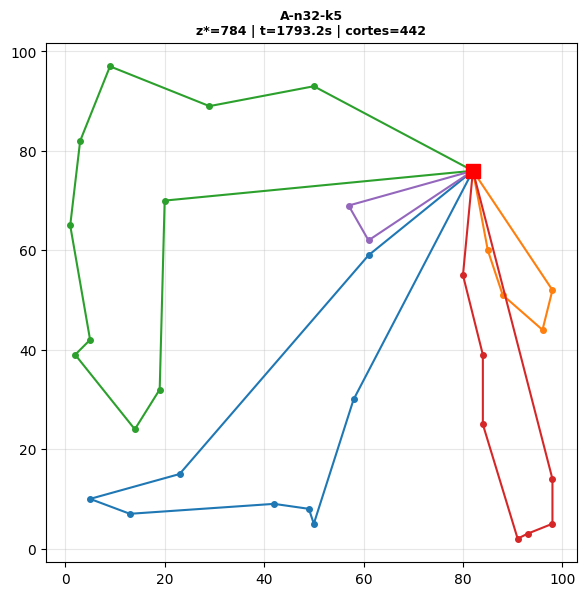

,Instancia,n,m,Óptimo,z*,Tiempo (s),Iteraciones,Cortes,Factible,Gap (%)
0,A-n32-k5,32,5,784,784.0,1793.24,322,442,True,0.0


In [ ]:
# ============================================================
# 5. Configuración y ejecución
# ============================================================

INSTANCES = [
     {"name": "A-n32-k5"},
#     {"name": "A-n33-k5"},
#     {"name": "A-n33-k6"},
#     {"name": "A-n34-k5"},
#     {"name": "A-n36-k5"},
#     {"name": "A-n37-k5"},
#     {"name": "A-n38-k5"},
#     {"name": "A-n39-k5"},
#     {"name": "A-n39-k6"},
#     {"name": "A-n44-k6"},
#     {"name": "A-n45-k7"},
#     {"name": "A-n46-k7"},
#     {"name": "A-n48-k7"},
]


runs_df, fig = run_experiment(INSTANCES, time_limit=60)
plt.show()
display(runs_df)

## 6. Resultados

In [ ]:
# ============================================================
# 6. Tablas de resultados
# ============================================================

print("RESULTADOS")
print("=" * 60)
display(runs_df)


## Resumen

| Aspecto | Detalle |
|---|---|
| **Formulación** | Simétrica de Laporte & Nobert (1983), Eq. 1-3 |
| **Método** | Branch & Bound (CBC) + cortes iterativos SEC/capacidad |
| **Solver** | PuLP + COIN-CBC |
| **Instancias** | A-n32-k5, A-n34-k5, A-n39-k6, etc (Set A, CVRPLIB) |
| **Ejecuciones** | 1 por instancia |

### Algoritmo (Laporte 1983, pág. 80)
1. Modelo base con restricciones de grado (Eq. 1-2), sin subtour/capacidad
2. Resolver con Branch & Bound (CBC)
3. Detectar subtours ilegales (componentes sin depósito) y violaciones de capacidad
4. Agregar corte Eq. 3 para cada subconjunto violado
5. Repetir hasta convergencia (sin nuevas violaciones)

### Referencias
1. Laporte, G. & Nobert, Y. (1983). *OR Spektrum*, 5, 77-85.
2. Augerat, P. et al. (1995). Tech. Report RR 949-M, IMAG.
3. CVRPLIB: http://vrp.atd-lab.inf.puc-rio.br/index.php/en/